# FEM for submerged tunnel as 3D beams

In [1]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Visualize the tunnel

- Radius = 2683 m
- Distance between landings = 3700 m
- Angular span = [68.2 deg, 111.8 deg]

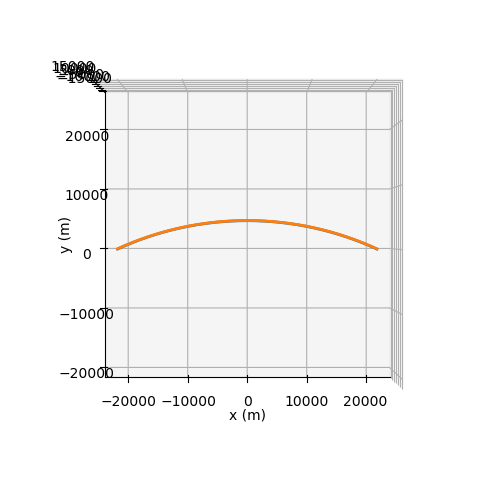

In [ ]:
TunRad = 50000 #m
TunAng = (114.65, 65.35) #deg
node_spacing = 54.0  

angle_start = np.deg2rad(TunAng[0])
angle_end = np.deg2rad(TunAng[1])
angle_step = node_spacing / TunRad
angles = np.arange(angle_start, angle_end - angle_step, -angle_step)

TunCX = TunRad*np.cos(angles)
TunCY = TunRad*np.sin(angles)
TunCZ = np.zeros_like(TunCX)

outerOffset = 30
TunRad2 = TunRad + outerOffset
TunCX2 = TunRad2*np.cos(angles)
TunCY2 = TunRad2*np.sin(angles)
TunCZ2 = np.zeros_like(TunCX2)

shiftY = -min(np.concatenate([TunCY, TunCY2])) + 5
TunCY += shiftY
TunCY2 += shiftY

ax = plt.axes(projection='3d')
ax.view_init(90, 270)
plt.plot(TunCX, TunCY, TunCZ, lw=2)
plt.plot(TunCX2, TunCY2, TunCZ2, lw=2)
plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')

TunCX = np.append(TunCX, TunCX2)
TunCY = np.append(TunCY, TunCY2)
TunCZ = np.append(TunCZ, TunCZ2)

## Properties of Beam

In [3]:
E = 36.0e9            
nu = 0.2      
rho_w = 1025
rho_c = 2650
g = 9.81
#tunnel
D_out = 20 #m  
D_in = 18 #m
dist_c2c = 30.0 #m
A_beton = (np.pi / 4) * (D_out**2 - D_in**2)
I_beam = (np.pi / 64) * (D_out**4 - D_in**4) 

#connectie
D_out_conn = 6.0; D_in_conn = 5.0; L_conn = 10.0
A_beton_conn = (np.pi / 4) * (D_out_conn**2 - D_in_conn**2)
I_beton_conn = (np.pi / 64) * (D_out_conn**4 - D_in_conn**4)


In [4]:
Beam_m =  A_beton * rho_c + 749.0e3 / g               # [kg/m]
Beam_EI = E * I_beam               # [N.m2]
Beam_EA = E * A_beton              # [N]
Beam_G = E / (2 * (1 + nu))
Beam_J = 0.623 * ((D_out /2) ** 4)
Beam_GJ = Beam_G * Beam_J            # [N.m2]
Beam_Im = rho_c * Beam_J          #[kg.m]

In [5]:
conn_m = A_beton_conn * rho_c         
conn_EI = E * I_beton_conn
conn_EA = E * A_beton_conn

conn_G = E / (2 * (1 + nu))
conn_J = 0.623 * ((D_out_conn / 2) ** 4)
conn_GJ = conn_G * conn_J            
conn_Im = rho_c * conn_J

## Mesh setup

In [ ]:
NodeC = [ [x,y,z] for x,y,z in zip(TunCX, TunCY, TunCZ) ]
nNode = len(NodeC)
nNodeTunnel = int(nNode/2)

def get_total_tube_mass_per_meter(node_index):
  
    x_pos_meter = node_index * node_spacing
    x_km = x_pos_meter / 1000.0
    
    if 0.0 <= x_km < 8.0: 
        F_ballast = 2425.33
    elif 8.0 <= x_km < 23.0: 
        F_ballast = 2408.77
    elif 23.0 <= x_km < 28.0: 
        F_ballast = 2352.75
    elif 28.0 <= x_km < 38.0: 
        F_ballast = 2405.78
    else: 
        F_ballast = 2424.70
        
    m_ballast = (F_ballast * 1000.0) / g
    
    A_buiten = (np.pi / 4) * (D_out**2)
    C_a_theory = 1.0
    added_mass_tube = rho_w * A_buiten * C_a_theory
    
    m_tot_meter = (A_beton * rho_c) + ((749.0e3 / g) / 2) + (m_ballast / 2) + added_mass_tube
    return m_tot_meter

def calc_mooring_tension_quasistatic(x_pos_meter, y):
    x_km = x_pos_meter / 1000.0
    y = np.abs(y)
    if 0.0 <= x_km < 8.0:
        #depth 70
        Kxx = 5.8535e-08*y**6 + 2.0441e-04*y**4 - 5.8406e-01*y**2 + 6.3969e+02
        Kyy = 3.7562e-07*y**6 + 9.2656e-05*y**4 - 1.9909e+00*y**2 + 3.3131e+03 
        Kzz = -3.1709e-07*y**6 + 1.1175e-04*y**4 + 1.4068e+00*y**2 + 2.6865e+03
        
        Kxy = 0.0
        Kxz = 0.0
        Kyz = 1.2233e-05*y**5 + 2.8621e-02*y**3 - 4.0884e+01*y
        Kzy = Kyz
        
    elif 8.0 <= x_km < 23.0:
        # depth 85
        Kxx = 5.8228e-05*y**4 + 2.4839e-02*y**2 + 2.2666e+00
        Kyy = 3.6259e-03*y**4 - 2.2938e-09*y**3 + 1.9153e+00*y**2 + 8.1052e-08*y + 1.2959e+02
        Kzz = -3.5615e-05*y**4 + 1.6451e-07*y**3 + 3.0463e-02*y**2 - 9.7324e-06*y + 2.9447e+01
        
        Kxy = 0.0
        Kxz = 0.0
        Kyz = 5.9264e-08*y**4 + 2.8380e-03*y**3 - 3.2791e-06*y**2 + 7.3545e+00*y - 1.8722e-05
        Kzy = 1.7855e-10*y**4 + 3.4391e-03*y**3 - 7.2761e-09*y**2 + 7.3616e+00*y + 3.2408e-08
        
    elif 23.0 <= x_km < 28.0:
        # depth 195
        Kxx = 1.2731e-06*y**4 + 1.1231e-02*y**2 - 7.3730e-10*y + 7.7236e+00
        Kyy = -2.4791e-04*y**4 - 2.5599e-07*y**3 + 5.0961e-01*y**2 + 4.1020e-06*y + 2.5505e+02
        Kzz = -9.8663e-06*y**4 + 2.2341e-08*y**3 - 4.2587e-03*y**2 - 3.4842e-06*y + 3.5755e+01
        
        Kxy = 0.0
        Kxz = 0.0
        Kyz = 1.6455e-09*y**4 - 1.8305e-03*y**3 - 2.4033e-07*y**2 + 3.7668e+00*y - 5.2388e-05
        Kzy = -1.2764e-09*y**4 - 1.5624e-03*y**3 - 3.8349e-07*y**2 + 3.8448e+00*y + 1.3642e-06
        
    elif 28.0 <= x_km < 38.0:
        # depth 95
        Kxx = 3.6582e-05*y**4 + 1.9991e-02*y**2 + 3.4152e+00
        Kyy = 2.2727e-03*y**4 + 1.2469e+00*y**2 + 7.8478e-10*y + 1.5125e+02
        Kzz = -6.0936e-05*y**4 - 6.6916e-08*y**3 + 2.9895e-02*y**2 + 5.0794e-06*y + 3.6658e+01
        
        Kxy = 0.0
        Kxz = 0.0
        Kyz = -7.6673e-08*y**4 + 6.1091e-03*y**3 + 5.3394e-06*y**2 + 4.8892e+00*y - 2.2527e-05
        Kzy = 6.5423e-03*y**3 + 4.9069e+00*y + 5.1146e-09
        
    else:
        # depth 60
        Kxx = 5.7481e-07*y**6 + 8.6913e-04*y**4 - 1.6229e+00*y**2 + 1.2548e+03
        Kyy = 3.2035e-06*y**6 - 1.1369e-04*y**4 - 5.0522e+00*y**2 + 5.0462e+03
        Kzz = -2.6287e-06*y**6 + 9.8282e-04*y**4 + 3.4292e+00*y**2 + 3.8877e+03
        
        Kxy = 0.0
        Kxz = 0.0
        Kyz = 8.5679e-05*y**5 + 8.6945e-02*y**3 - 8.1147e+01*y
        Kzy = Kyz
        
        
    Kxx = max(Kxx, 1e-6)
    Kyy = max(Kyy, 1e-6)
    Kzz = max(Kzz, 1e-6)
    return Kxx*1000, Kyy*1000, Kzz*1000, Kxy*1000, Kxz*1000, Kyz*1000, Kzy*1000

In [ ]:
Ele = []

for i in range(0, nNodeTunnel - 1):
    m_dynamisch = get_total_tube_mass_per_meter(2*i)
    Ele.append([int(i), int(i + 1), m_dynamisch, Beam_EA, Beam_EI, Beam_GJ, Beam_Im])

for i in range(0, nNodeTunnel - 1):
    n1 = i + nNodeTunnel
    n2 = n1 + 1
    m_dynamisch = get_total_tube_mass_per_meter(2*i)
    Ele.append([int(n1), int(n2), m_dynamisch, Beam_EA, Beam_EI, Beam_GJ, Beam_Im])

connector_interval = 8
for i in range(0, nNodeTunnel, connector_interval):
    n1 = i
    n2 = i + nNodeTunnel
    if n2 < nNode:
        Ele.append([int(n1), int(n2), conn_m, conn_EA, conn_EI, conn_GJ, conn_Im])

nEle = len(Ele)

print(f"Totaal aantal knopen (nNode): {nNode}")
print(f"Totaal aantal elementen (nEle) inclusief connectoren: {nEle}")

connectoren_gevonden = 0
for el in Ele:

    if int(round(el[1])) - int(round(el[0])) == nNodeTunnel:
        connectoren_gevonden += 1

print(f"Aantal actieve connectoren in de elementenlijst: {connectoren_gevonden}")

Totaal aantal knopen (nNode): 1596
Totaal aantal elementen (nEle) inclusief connectoren: 1694
Aantal actieve connectoren in de elementenlijst: 100


Listing the nodes and elements. <br>
Plot the mesh setup for reference.

Nodes
Elements


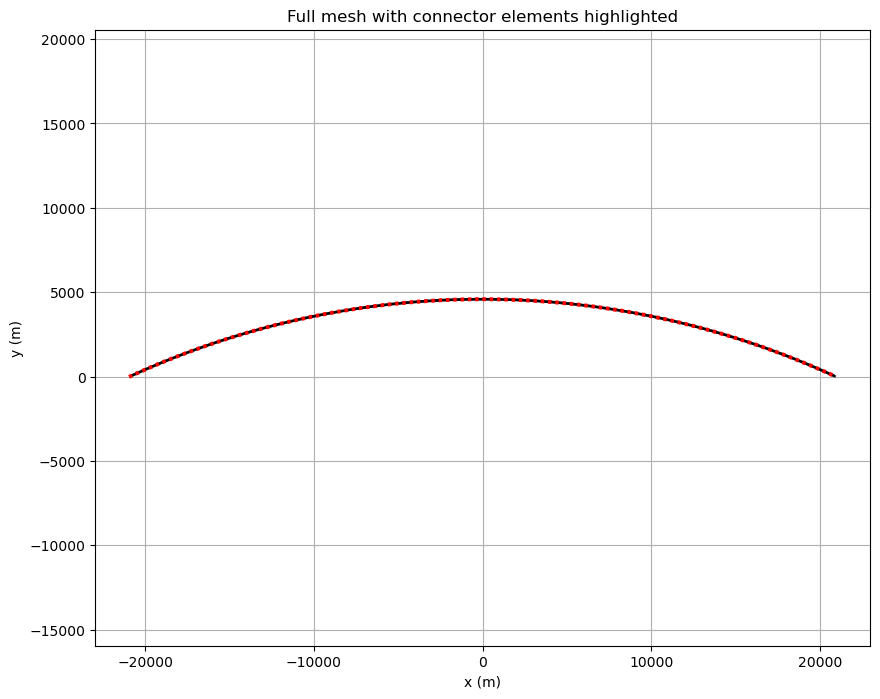

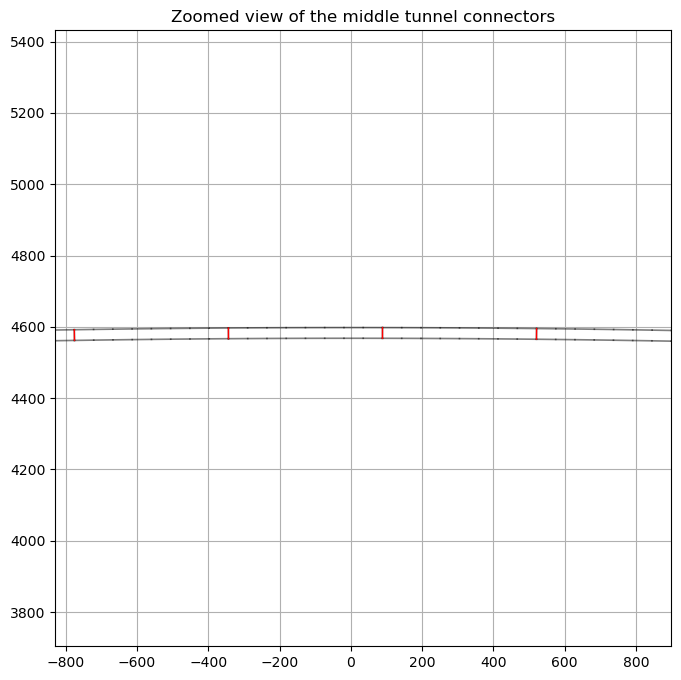

In [ ]:
print("Nodes")

NodeC_arr = np.array(NodeC)

plt.figure(figsize=(10, 8))
print("Elements")
for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    plt.plot([NodeC[n1][0], NodeC[n2][0]],
             [NodeC[n1][1], NodeC[n2][1]],
             lw=1.5, color='k', alpha=0.5)

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    if abs(n2 - n1) > 1: # Filter die de cross-passages herkent
        plt.plot([NodeC_arr[n1,0], NodeC_arr[n2,0]],
                 [NodeC_arr[n1,1], NodeC_arr[n2,1]],
                 lw=2.5, color='red')

plt.grid(True)
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Full mesh with connector elements highlighted')

center_index = nNodeTunnel // 2
x_center = NodeC_arr[center_index, 0]
y_center = NodeC_arr[center_index, 1]
span = 1000

fig, ax = plt.subplots(figsize=(10, 8))

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    ax.plot([NodeC[n1][0], NodeC[n2][0]],
            [NodeC[n1][1], NodeC[n2][1]],
            lw=1.2, color='k', alpha=0.5)

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    if abs(n2 - n1) > 1:
        ax.plot([NodeC_arr[n1,0], NodeC_arr[n2,0]],
                [NodeC_arr[n1,1], NodeC_arr[n2,1]],
                lw=1, color='red')

span = 864 # (16 nodes * 54m)
ax.set_xlim(x_center - span, x_center + span)
ax.set_ylim(y_center - span, y_center + span)

ax.set_aspect('equal')
ax.grid(True)
ax.set_title('Zoomed view of the middle tunnel connectors')
pass

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

| <img width="50%" src="./img/nb09_f01_3Ddofs_nptel.png" /> |
| :---- |
| Fig 1: Definition of 3 dofs per node, for the 2 noded elements. (This is from my lectures slides. To Be replaced) |

$$ M = \frac{mL}{420} 
\begin{bmatrix} 
140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 156 & 0 & 0 & 0 & 22L & 0 & 54 & 0 & 0 & 0 & -13L \\ 
0 & 0 & 156 & 0 & 22L & 0 & 0 & 0 & 54 & 0 & 13L & 0 \\ 
0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 \\ 
0 & 0 & 22L & 0 & 4L^2 & 0 & 0 & 0 & -13L & 0 & -3L^2 & 0 \\ 
0 & 22L & 0 & 0 & 0 & 4L^2 & 0 & 13L & 0 & 0 & 0 & -3L^2 \\ 
70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 54 & 0 & 0 & 0 & 13L & 0 & 156 & 0 & 0 & 0 & -22L \\ 
0 & 0 & 54 & 0 & -13L & 0 & 0 & 0 & 156 & 0 & 22L & 0 \\ 
0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 \\ 
0 & 0 & 13L & 0 & -3L^2 & 0 & 0 & 0 & 22L & 0 & 4L^2 & 0 \\
0 & -13L & 0 & 0 & 0 & -3L^2 & 0 & -22L & 0 & 0 & 0 & 4L^2
\end{bmatrix} $$
$$ \quad K = 
\begin{bmatrix} 
\frac{EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{-EA}{L} &  0 & 0 & 0 & 0 & 0\\ 
0 & \frac{12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} \\ 
0 & 0 & \frac{12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{-12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & \frac{-6EI}{L^2} & 0 & \frac{4EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} \\ 
\frac{-EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{EA}{L} & 0 & 0 & 0 & 0 & 0 \\ 
0 & -\frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} \\ 
0 & 0 & -\frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{4EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L}
\end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [ ]:
import time
import numpy as np
from BeamMatrices import Beam3DMatrices

LDOF = 6
nDof = LDOF * nNode  # 6 dof per node


K = np.zeros(nDof * nDof)
M = np.zeros(nDof * nDof)
Q = np.zeros(nDof * nDof)

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

for iEle in range(0, nEle):
    n1 = int(round(Ele[iEle][0]))
    n2 = int(round(Ele[iEle][1]))
    
    n1dof = LDOF * n1 + np.arange(0, LDOF)
    n2dof = LDOF * n2 + np.arange(0, LDOF)    
    indexes = np.append(n1dof, n2dof)
    
   
    Me, Ke, Qe = Beam3DMatrices(Ele[iEle][2], Ele[iEle][3], Ele[iEle][4], Ele[iEle][5], Ele[iEle][6], (NodeC[n1], NodeC[n2]))
    
    if (n2 - n1) == nNodeTunnel:  
        dx = NodeC[n2][0] - NodeC[n1][0]
        dy = NodeC[n2][1] - NodeC[n1][1]
        L = np.sqrt(dx**2 + dy**2)
        
        cx = dx / L
        cy = dy / L
        
        T_corr = np.array([[-cy, cx, 0], 
                           [-cx, -cy, 0], 
                           [0, 0, 1]])
        
        T_element = np.zeros((12, 12))
        for i_block in range(4):
            T_element[i_block*3:(i_block+1)*3, i_block*3:(i_block+1)*3] = T_corr
            
        Ke = T_element.T @ Ke @ T_element
        Me = T_element.T @ Me @ T_element
        Qe = T_element.T @ Qe @ T_element

    for i in range(0, 2 * LDOF):
        for j in range(0, 2 * LDOF):
            ij = indexes[i] * nDof + indexes[j]
            M[ij] = M[ij] + Me[i, j]
            K[ij] = K[ij] + Ke[i, j]
            Q[ij] = Q[ij] + Qe[i, j]

M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))


exeTime[1] = time.time()
print("Handmatige assemblage succesvol voltooid!")
print("Execution time = {:.4f} s".format(exeTime[1] - exeTime[0]))

Handmatige assemblage succesvol voltooid!
Execution time = 0.4596 s


## Boundary conditions

To apply the boundary conditions, we will remove the rows associated to the fixed DOFs and add the contribution to the right-hand-side. First, we obtain the free and fixed DOFs.

[   0    1    2    3    4    5 4782 4783 4784 4785 4786 4787 4788 4789
 4790 4791 4792 4793 9570 9571 9572 9573 9574 9575]
[   6    7    8 ... 9567 9568 9569]


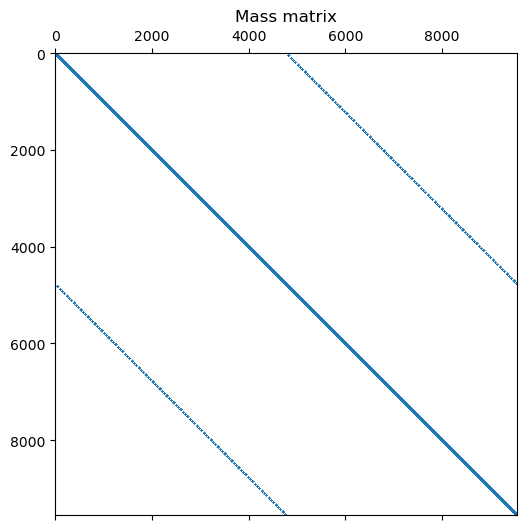

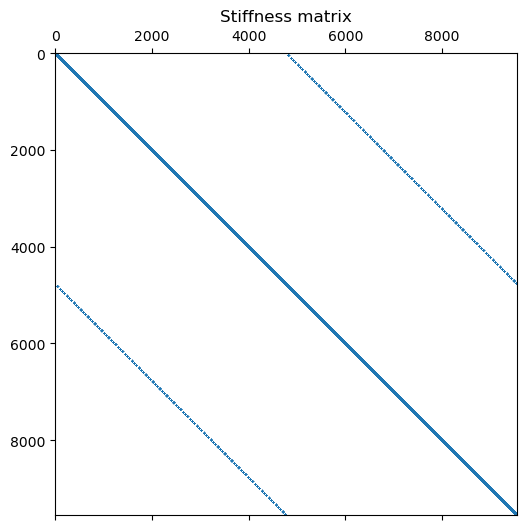

In [ ]:
NodesClamp = (0, int(round(nNode/2-1)), int(round(nNode/2)), nNode-1)

DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

# Free dofs
DofsF = np.arange(0, nDof)       
DofsF = np.delete(DofsF, DofsP) 

print(DofsP)
print(DofsF)

M_FF = [ M[iRow,DofsF].tolist() for iRow in DofsF ]
K_FF = [ K[iRow,DofsF].tolist() for iRow in DofsF ]
Q_FF = [ Q[iRow,DofsF].tolist() for iRow in DofsF ]

plt.figure()
plt.spy(M_FF, markersize=0.2)
plt.title("Mass matrix")
plt.figure()
plt.spy(K_FF, markersize=0.2)
plt.title("Stiffness matrix")
pass

## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [12]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)
w2, vr = np.linalg.eig(mat)
w = np.sqrt(w2.real)
f = w/2/np.pi
print(len(f))

9552


C:\Users\pipsl\AppData\Local\Temp\ipykernel_22968\367166604.py:3: RuntimeWarning: invalid value encountered in sqrt
  w = np.sqrt(w2.real)


In [13]:
idx = f.argsort()
f = f[idx]
vr = vr[:,idx]

print(f)

[2.35780101e-05 3.59657962e-05 6.06507385e-05 ...            nan
            nan            nan]


In [14]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr

9552


<>:73: SyntaxWarning: invalid escape sequence '\o'
<>:118: SyntaxWarning: invalid escape sequence '\e'
<>:127: SyntaxWarning: invalid escape sequence '\e'
<>:73: SyntaxWarning: invalid escape sequence '\o'
<>:118: SyntaxWarning: invalid escape sequence '\e'
<>:127: SyntaxWarning: invalid escape sequence '\e'
C:\Users\pipsl\AppData\Local\Temp\ipykernel_22968\3684733559.py:73: SyntaxWarning: invalid escape sequence '\o'
  ax1.axvline(omega_p, color='crimson', linestyle='--', label=f'Peak frequency $\omega_p$ ({omega_p:.2f} rad/s)')
C:\Users\pipsl\AppData\Local\Temp\ipykernel_22968\3684733559.py:118: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(t_pre[mask_eta], eta_pre[mask_eta], color='steelblue', linewidth=1.5, label='Wateroppervlakte $\eta(t)$')
C:\Users\pipsl\AppData\Local\Temp\ipykernel_22968\3684733559.py:127: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("Elevatie $\eta$ [m]", fontsize=11)


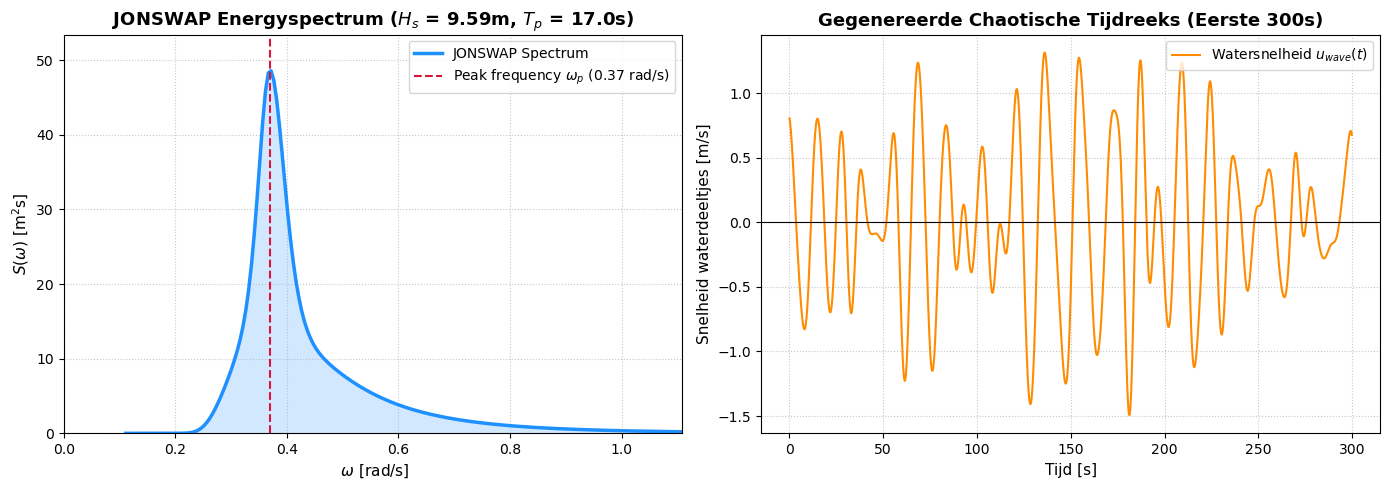

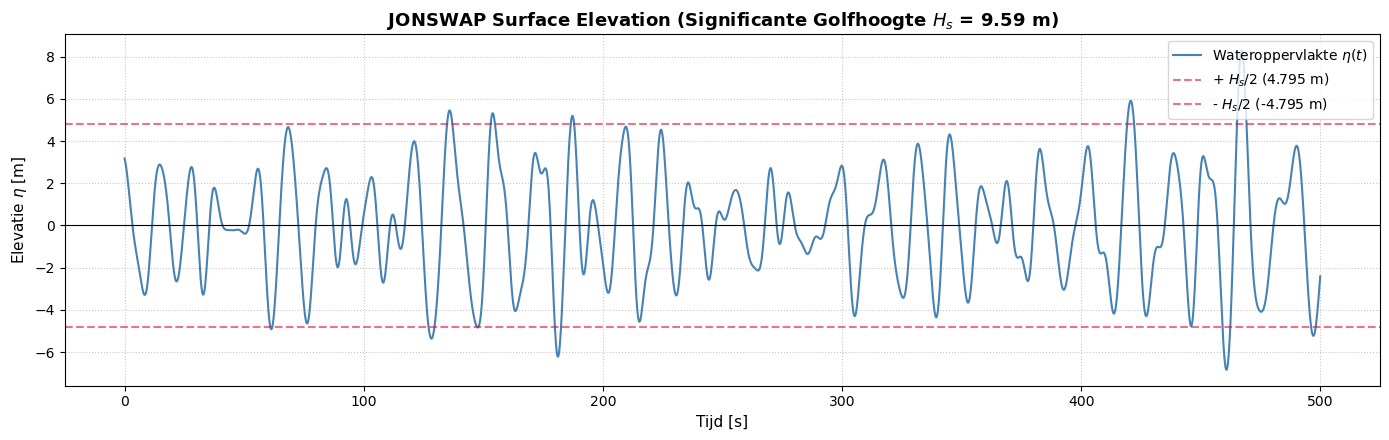

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scpi
from scipy.interpolate import interp1d


rho_w = 1025.0       
U = 1.44             
H_s = 9.59          
T_p = 17.0           
z_axis = 25.0        
D_out = 20.0         
dist_c2c = 30.0      
C_d = 0.75           
C_m_coef = 2.0       
h = 54.0             
zeta = 0.05    

g = 9.81
t_sim = 1000.0                     
t_eval = np.arange(500, t_sim, 0.1)

C_s = 1.0 - 2.0 * 0.95 * np.sqrt((C_d * D_out) / (dist_c2c + 6.0 * D_out))


omega_p = (2 * np.pi) / T_p
gamma = 3.3  

N_freq = 200
omega = np.linspace(0.3 * omega_p, 3.0 * omega_p, N_freq)
d_omega = omega[1] - omega[0]

sigma = np.where(omega <= omega_p, 0.07, 0.09)
A = np.exp(-1.25 * (omega_p / omega)**4)
B = np.exp(-0.5 * ((omega - omega_p) / (sigma * omega_p))**2)
S_unscaled = (g**2 / omega**5) * A * (gamma**B)

m0_unscaled = np.trapezoid(S_unscaled, omega)
schaalfactor = (H_s / 4)**2 / m0_unscaled
S_omega = S_unscaled * schaalfactor

a_i = np.sqrt(2 * S_omega * d_omega)
np.random.seed(42)  
fase_i = np.random.uniform(0, 2 * np.pi, N_freq)
k_i = (omega**2) / g 

t_pre = np.linspace(0, t_sim + 10, int((t_sim + 10) * 10)) 
u_wave_pre = np.zeros_like(t_pre)
a_wave_pre = np.zeros_like(t_pre)


t_pre = np.linspace(0, t_sim + 10, int((t_sim + 10) * 10)) 
u_wave_pre = np.zeros_like(t_pre)
a_wave_pre = np.zeros_like(t_pre)

for i in range(N_freq):
    fase_t = omega[i] * t_pre + fase_i[i]
    verval_factor = np.exp(-k_i[i] * z_axis)
    
    u_wave_pre += a_i[i] * omega[i] * verval_factor * np.cos(fase_t)
    a_wave_pre -= a_i[i] * (omega[i]**2) * verval_factor * np.sin(fase_t)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ax1.plot(omega, S_omega, color='dodgerblue', linewidth=2.5, label='JONSWAP Spectrum')
# ax1.axvline(omega_p, color='crimson', linestyle='--', label=f'Peak frequency $\omega_p$ ({omega_p:.2f} rad/s)')
# ax1.fill_between(omega, 0, S_omega, color='dodgerblue', alpha=0.2)

# ax1.set_title(f"JONSWAP Energyspectrum ($H_s$ = {H_s}m, $T_p$ = {T_p}s)", fontsize=13, fontweight='bold')
# ax1.set_xlabel(r" $\omega$ [rad/s]", fontsize=11)
# ax1.set_ylabel(r"$S(\omega)$ [m$^2$s]", fontsize=11)
# ax1.set_xlim(0, max(omega))
# ax1.set_ylim(0, max(S_omega) * 1.1)
# ax1.grid(True, linestyle=':', alpha=0.7)
# ax1.legend()


# mask = t_pre <= 300
# ax2.plot(t_pre[mask], u_wave_pre[mask], color='darkorange', linewidth=1.5, label='Watersnelheid $u_{wave}(t)$')

# ax2.set_title("Gegenereerde Chaotische Tijdreeks (Eerste 300s)", fontsize=13, fontweight='bold')
# ax2.set_xlabel("Tijd [s]", fontsize=11)
# ax2.set_ylabel("Snelheid waterdeeltjes [m/s]", fontsize=11)
# ax2.axhline(0, color='black', linewidth=0.8)
# ax2.grid(True, linestyle=':', alpha=0.7)
# ax2.legend(loc='upper right')

# plt.tight_layout()
# plt.show()

# eta_pre = np.zeros_like(t_pre)

# for i in range(N_freq):
#     fase_t = omega[i] * t_pre + fase_i[i]

#     eta_pre += a_i[i] * np.cos(fase_t)

# plt.figure(figsize=(14, 4.5))

# mask_eta = t_pre <= 500

# plt.plot(t_pre[mask_eta], eta_pre[mask_eta], color='steelblue', linewidth=1.5, label='Wateroppervlakte $\eta(t)$')

# plt.axhline(H_s / 2, color='crimson', linestyle='--', alpha=0.6, label=f'+ $H_s/2$ ({H_s/2} m)')
# plt.axhline(-H_s / 2, color='crimson', linestyle='--', alpha=0.6, label=f'- $H_s/2$ ({-H_s/2} m)')

# plt.title(f"JONSWAP Surface Elevation (Significante Golfhoogte $H_s$ = {H_s} m)", fontsize=13, fontweight='bold')
# plt.xlabel("Tijd [s]", fontsize=11)
# plt.ylabel("Elevatie $\eta$ [m]", fontsize=11)
# plt.axhline(0, color='black', linewidth=0.8) # Mean Water Level (MWL)
# plt.grid(True, linestyle=':', alpha=0.7)

# plt.legend(loc='upper right')
# plt.tight_layout()

# plt.show()


u_wave_interp = interp1d(t_pre, u_wave_pre, kind='cubic')
a_wave_interp = interp1d(t_pre, a_wave_pre, kind='cubic')


In [ ]:
nMode = 5000
print(f"--- START SOLVER MET {nMode} GEKOZEN MODES ---")

PHI = vr[:, :nMode]
f_gekozen = f[:nMode]
M_FF_np = np.array(M_FF)

Mm = np.zeros(nMode)
Km = np.zeros(nMode)
Cm = np.zeros(nMode)

for i in range(nMode):
    omega_i = 2 * np.pi * f_gekozen[i]
    print(f"  > Mode {i}: Freq = {f_gekozen[i]:.3f} Hz ingeladen.")
    Mm[i] = np.dot(PHI[:, i].T, np.dot(M_FF_np, PHI[:, i]))
    Km[i] = (omega_i**2) * Mm[i]
    Cm[i] = 2 * zeta * omega_i * Mm[i]


ruimtelijke_kracht_verdeling = np.zeros(len(DofsF))
for idx, dof in enumerate(DofsF):
    if dof % LDOF == 1: 
        ruimtelijke_kracht_verdeling[idx] = 1.0 if dof < (nDof // 2) else C_s

mooring_nodes = []
for i in range(0, nNodeTunnel, connector_interval):
    x_k1 = i * node_spacing
    dof_start_k1 = i * LDOF
    mooring_nodes.append({'x': x_k1, 'dofs': [dof_start_k1, dof_start_k1+1, dof_start_k1+2]})
    
    n_k2 = i 
    x_k2 = n_k2 * node_spacing
    dof_start_k2 = n_k2 * LDOF
    mooring_nodes.append({'x': x_k2, 'dofs': [dof_start_k2, dof_start_k2+1, dof_start_k2+2]})

for node in mooring_nodes:
    node['idx_map'] = []
    for dof in node['dofs']:
        idx = np.where(DofsF == dof)[0]
        node['idx_map'].append(idx[0] if len(idx) > 0 else None)

def P_modaal(t, Um, Vm):
    u_wave_t = u_wave_interp(t)
    a_wave_t = a_wave_interp(t)
    
    V_fysiek = PHI @ Vm 
    
    u_rel = (U + u_wave_t) - V_fysiek
    
    F_drag = 0.5 * rho_w * C_d * D_out * u_rel * np.abs(u_rel)
    F_inertia = rho_w * C_m_coef * (np.pi * (D_out**2) / 4) * a_wave_t
    
    F_fysiek = (F_drag + F_inertia) * h * ruimtelijke_kracht_verdeling

    U_fysiek = PHI @ Um
    F_mooring_fysiek = np.zeros(len(DofsF))

    for node in mooring_nodes:
        u = np.zeros(3)
        for j in range(3):
            if node['idx_map'][j] is not None:
                u[j] = U_fysiek[node['idx_map'][j]]
                
        Kxx, Kyy, Kzz, Kxy, Kxz, Kyz, Kzy = calc_mooring_tension_quasistatic(node['x'], u[1])
        
        Fx = Kxx*u[0] + Kxy*u[1] + Kxz*u[2]
        Fy = Kxy*u[0] + Kyy*u[1] + Kyz*u[2]
        Fz = Kxz*u[0] + Kzy*np.abs(u[1]) + Kzz*u[2]  
        
        if node['idx_map'][0] is not None: F_mooring_fysiek[node['idx_map'][0]] -= Fx
        if node['idx_map'][1] is not None: F_mooring_fysiek[node['idx_map'][1]] -= Fy
        if node['idx_map'][2] is not None: F_mooring_fysiek[node['idx_map'][2]] -= Fz
    
    return PHI.T @ (F_fysiek + F_mooring_fysiek)

def qdot(t, q):
    Um = q[0:nMode]          
    Vm = q[nMode:2*nMode]    
    Am = (P_modaal(t, Um, Vm) - (Km * Um + Cm * Vm)) / Mm
    return np.append(Vm, Am)

q0 = np.zeros(2 * nMode)          




--- START SOLVER MET 5000 GEKOZEN MODES ---
  > Mode 0: Freq = 0.000 Hz ingeladen.
  > Mode 1: Freq = 0.000 Hz ingeladen.
  > Mode 2: Freq = 0.000 Hz ingeladen.
  > Mode 3: Freq = 0.000 Hz ingeladen.
  > Mode 4: Freq = 0.000 Hz ingeladen.
  > Mode 5: Freq = 0.000 Hz ingeladen.
  > Mode 6: Freq = 0.000 Hz ingeladen.
  > Mode 7: Freq = 0.000 Hz ingeladen.
  > Mode 8: Freq = 0.000 Hz ingeladen.
  > Mode 9: Freq = 0.000 Hz ingeladen.
  > Mode 10: Freq = 0.000 Hz ingeladen.
  > Mode 11: Freq = 0.000 Hz ingeladen.
  > Mode 12: Freq = 0.000 Hz ingeladen.
  > Mode 13: Freq = 0.000 Hz ingeladen.
  > Mode 14: Freq = 0.000 Hz ingeladen.
  > Mode 15: Freq = 0.000 Hz ingeladen.
  > Mode 16: Freq = 0.000 Hz ingeladen.
  > Mode 17: Freq = 0.000 Hz ingeladen.
  > Mode 18: Freq = 0.000 Hz ingeladen.
  > Mode 19: Freq = 0.000 Hz ingeladen.
  > Mode 20: Freq = 0.000 Hz ingeladen.
  > Mode 21: Freq = 0.000 Hz ingeladen.
  > Mode 22: Freq = 0.000 Hz ingeladen.
  > Mode 23: Freq = 0.001 Hz ingeladen.
  > Mo

In [ ]:
sol = scpi.solve_ivp(fun=qdot, y0=q0, t_span=[0, t_sim], t_eval=t_eval, method='Radau', rtol=1e-4, atol=1e-6)
print(f"Jacobian evaluations (njev): {sol.njev}")

Jacobian evaluations (njev): 8


Dynamic response

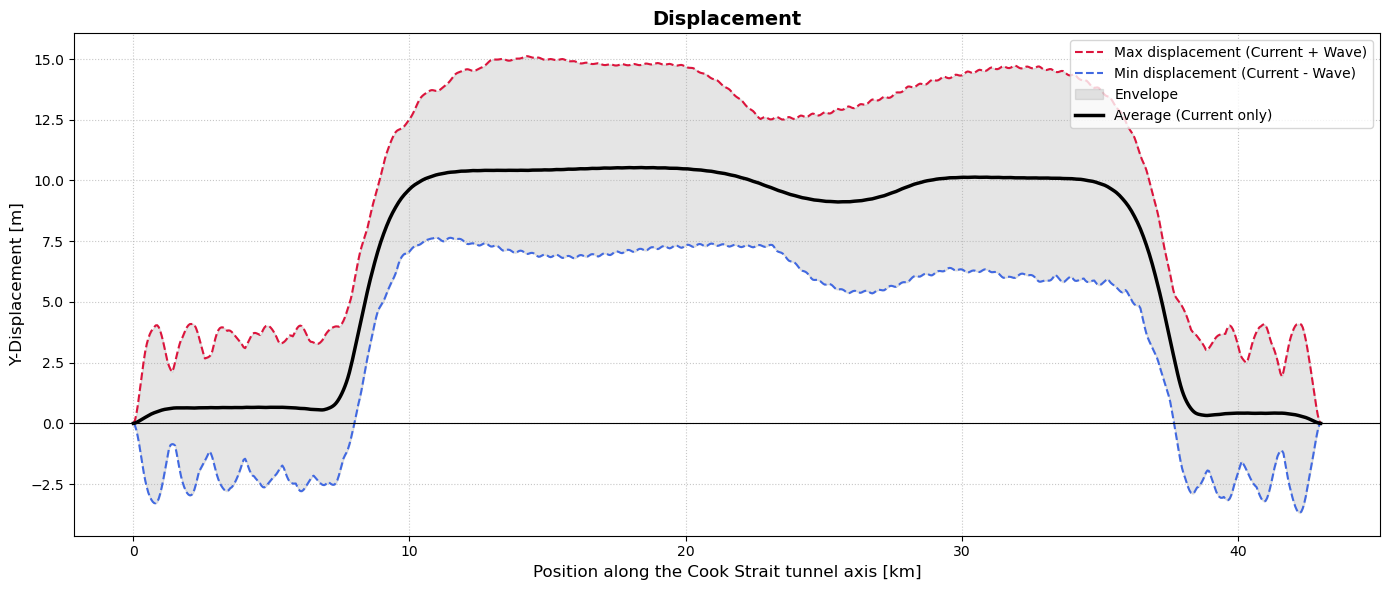

--- ANALYSE GEHELE TUNNEL (Koker 1) ---
Maximale positieve uitslag (Current + Wave): 15.1188 m
Maximale negatieve uitslag (Current - Wave): -3.6860 m


In [ ]:

if sol.success:
    U_F = (PHI @ sol.y[:nMode, :]).T 

    U_volledig = np.zeros((len(sol.t), nDof))
    U_volledig[:, DofsF] = U_F

    U_y_alle_nodes = U_volledig[:, 1::LDOF]

    n_nodes_koker1 = U_y_alle_nodes.shape[1] // 2
    U_y_koker1 = U_y_alle_nodes[:, :n_nodes_koker1]

    max_uitslag_tunnel = np.max(U_y_koker1, axis=0)  
    min_uitslag_tunnel = np.min(U_y_koker1, axis=0)  
    gemiddelde_buiging = np.mean(U_y_koker1, axis=0) 


    x_as_km = np.linspace(0, 43.0, n_nodes_koker1)

    plt.figure(figsize=(14, 6))
    
    plt.plot(x_as_km, max_uitslag_tunnel, color='crimson', linestyle='--', linewidth=1.5, label='Max displacement (Current + Wave)')
    plt.plot(x_as_km, min_uitslag_tunnel, color='royalblue', linestyle='--', linewidth=1.5, label='Min displacement (Current - Wave)')
    
    plt.fill_between(x_as_km, min_uitslag_tunnel, max_uitslag_tunnel, color='gray', alpha=0.2, label='Envelope')
    plt.plot(x_as_km, gemiddelde_buiging, color='black', linewidth=2.5, label='Average (Current only)', zorder=5)

    plt.title("Displacement", fontsize=14, fontweight='bold')
    plt.xlabel("Position along the Cook Strait tunnel axis [km]", fontsize=12)
    plt.ylabel("Y-Displacement [m]", fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8) # Reference line at 0 meter
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    print("--- ANALYSE GEHELE TUNNEL (Koker 1) ---")
    print(f"Maximale positieve uitslag (Current + Wave): {np.max(max_uitslag_tunnel):.4f} m")
    print(f"Maximale negatieve uitslag (Current - Wave): {np.min(min_uitslag_tunnel):.4f} m")

else:
    print("Solver is vastgelopen:", sol.message)


Bezig met het reconstrueren van de versnellingen over de gehele tunnel...


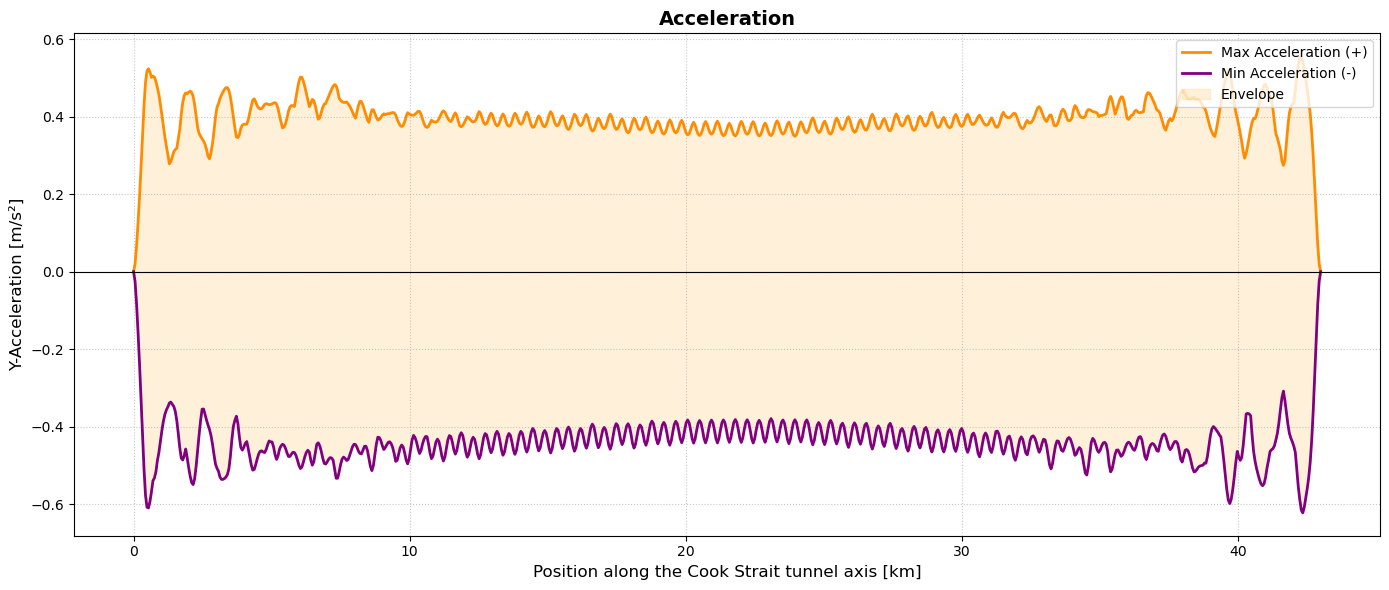

--- VERSNELLINGSANALYSE (Koker 1) ---
Grootste absolute versnelling: 0.5564 m/s²
Deze piek treedt op rond kilometer: 42.3 km
-> Versnelling is acceptabel voor gebruik.


In [ ]:

print("\nBezig met het reconstrueren van de versnellingen over de gehele tunnel...")

if sol.success:

    Am_totaal = np.zeros((nMode, len(sol.t)))

    for i, t_i in enumerate(sol.t):
        Um_i = sol.y[0:nMode, i]
        Vm_i = sol.y[nMode:2*nMode, i]
        Am_totaal[:, i] = (P_modaal(t_i, Um_i, Vm_i) - (Km * Um_i + Cm * Vm_i)) / Mm

    A_F = (PHI @ Am_totaal).T  
    A_volledig = np.zeros((len(sol.t), nDof))
    A_volledig[:, DofsF] = A_F

    A_y_alle_nodes = A_volledig[:, 1::LDOF]
    A_y_koker1 = A_y_alle_nodes[:, :n_nodes_koker1]

    max_acc_tunnel = np.max(A_y_koker1, axis=0)  
    min_acc_tunnel = np.min(A_y_koker1, axis=0)  

    plt.figure(figsize=(14, 6))
    
    plt.plot(x_as_km, max_acc_tunnel, color='darkorange', linestyle='-', linewidth=2, label='Max Acceleration (+)')
    plt.plot(x_as_km, min_acc_tunnel, color='purple', linestyle='-', linewidth=2, label='Min Acceleration (-)')
    
    plt.fill_between(x_as_km, min_acc_tunnel, max_acc_tunnel, color='orange', alpha=0.15, label='Envelope')
    
    plt.title("Acceleration", fontsize=14, fontweight='bold')
    plt.xlabel("Position along the Cook Strait tunnel axis [km]", fontsize=12)
    plt.ylabel("Y-Acceleration [m/s²]", fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    absolute_max_acc = np.max(np.abs(max_acc_tunnel))
    node_met_max_acc = np.argmax(np.abs(max_acc_tunnel))
    km_max_acc = x_as_km[node_met_max_acc]
    
    print("--- VERSNELLINGSANALYSE (Koker 1) ---")
    print(f"Grootste absolute versnelling: {absolute_max_acc:.4f} m/s²")
    print(f"Deze piek treedt op rond kilometer: {km_max_acc:.1f} km")
    
    if absolute_max_acc > 1.0:
        print("-> LET OP: Versnelling > 1.0 m/s²! Dit is zeer hoog voor het comfort van treinpassagiers/auto's.")
    else:
        print("-> Versnelling is acceptabel voor gebruik.")

--- KRITISCHE KNOOP GEVONDEN ---
Node nummer: 784
Locatie op de tunnel: 42.30 km vanaf de kust


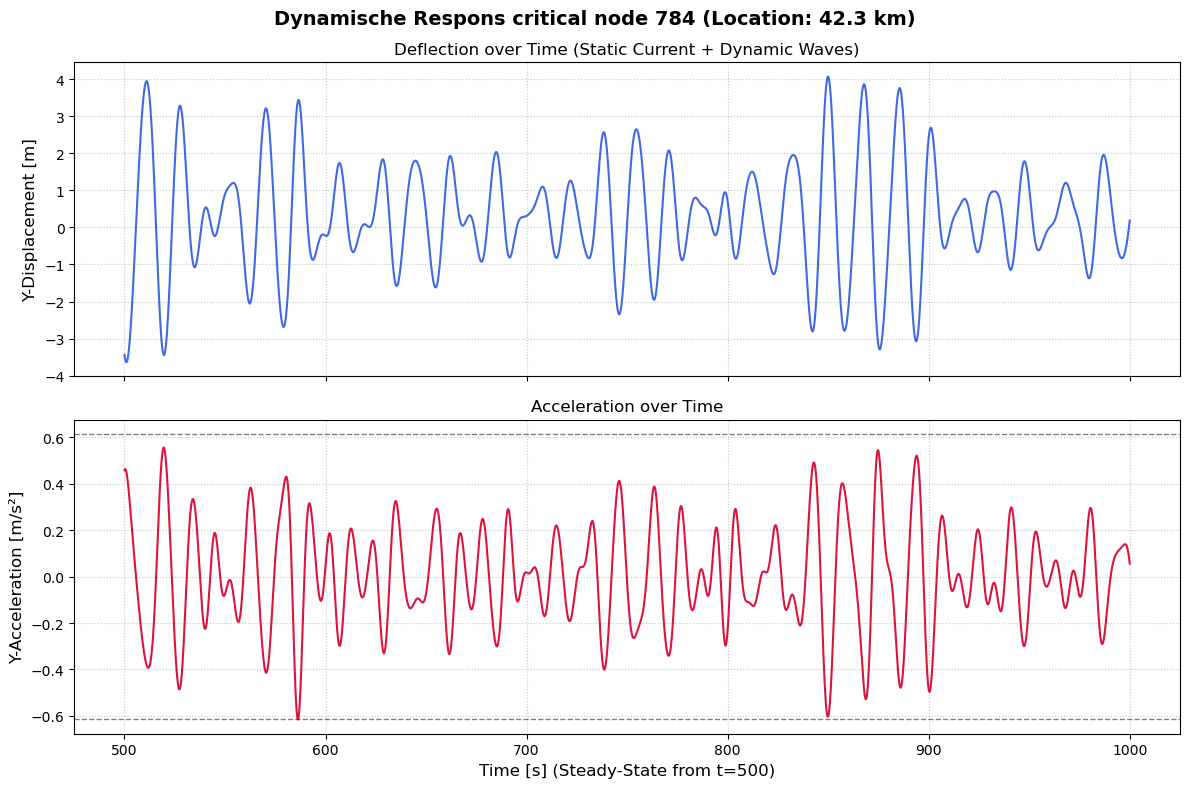


Data voor Node 784:
- Maximale Y-uitslag:   4.07 m
- Minimale Y-uitslag:   -3.64 m
- Maximale versnelling: 0.6153 m/s²


In [ ]:
kritische_knoop = node_met_max_acc 
locatie_km = x_as_km[kritische_knoop]

print(f"--- KRITISCHE KNOOP GEVONDEN ---")
print(f"Node nummer: {kritische_knoop}")
print(f"Locatie op de tunnel: {locatie_km:.2f} km vanaf de kust")

U_kritisch = U_y_koker1[:, kritische_knoop]
A_kritisch = A_y_koker1[:, kritische_knoop]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

fig.suptitle(f"Dynamische Respons critical node {kritische_knoop} (Location: {locatie_km:.1f} km)", fontsize=14, fontweight='bold')

ax1.plot(sol.t, U_kritisch, color='royalblue', linewidth=1.5)
ax1.set_ylabel("Y-Displacement [m]", fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.set_title("Deflection over Time (Static Current + Dynamic Waves)", fontsize=12)

ax2.plot(sol.t, A_kritisch, color='crimson', linewidth=1.5)
ax2.set_xlabel("Time [s] (Steady-State from t=500)", fontsize=12)
ax2.set_ylabel("Y-Acceleration [m/s²]", fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.set_title("Acceleration over Time", fontsize=12)

max_acc = np.max(np.abs(A_kritisch))
ax2.axhline(max_acc, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(-max_acc, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nData voor Node {kritische_knoop}:")
print(f"- Maximale Y-uitslag:   {np.max(U_kritisch):.2f} m")
print(f"- Minimale Y-uitslag:   {np.min(U_kritisch):.2f} m")
print(f"- Maximale versnelling: {max_acc:.4f} m/s²")

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# U_current = 1.44      # Stroomsnelheid [m/s]
# D_buiten = 20.0       # Buitendiameter tunnel [m]

# n_modes_totaal = len(f)

# modes_x = np.arange(1, n_modes_totaal + 1)

# Vr_plot = U_current / (f * D_buiten)

# plt.figure(figsize=(12, 6))

# plt.semilogy(modes_x, Vr_plot, color='tab:blue', linestyle='-', linewidth=2.0, label='$V_r$ (All Modes)')

# plt.axhspan(4.0, 10.0, color='red', alpha=0.2, label='Lock-in Region (4 < $V_r$ < 10)')

# plt.title(f"VIV Check: Reduced Velocity for all {n_modes_totaal} modes", fontsize=14, fontweight='bold')
# plt.xlabel("Mode Number (Physical Vibration Mode)", fontsize=12)
# plt.ylabel("Reduced Velocity $V_r$ [-]", fontsize=12)

# plt.grid(True, which='major', linestyle='-', alpha=0.7)
# plt.grid(True, which='minor', linestyle=':', alpha=0.4)

# plt.legend(loc='upper right')
# plt.tight_layout()
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# U_stroom = 1.44          # Watersnelheid [m/s]
# rho_w = 1025.0           # Dichtheid water [kg/m3]
# rho_staal = 7850.0       # Dichtheid staal (ketting) [kg/m3]
# rho_poly = 1380.0        # Dichtheid polyester touw [kg/m3] (Typische offshore waarde)

# # L_chain = Bottom chain + Top chain
# mooring_data = [
#     {"naam": "Lijn 1 (L=445m)", "L_chain": 0,   "L_poly": 1002,  "L_tot": 1002, "T_max_kN": 1724,  "D_chain_mm": 0, "D_poly_mm": 112},
#     {"naam": "Lijn 2 (L=455m)", "L_chain": 300+77,  "L_poly": 75, "L_tot": 455, "T_max_kN": 1939, "D_chain_mm": 54, "D_poly_mm": 138},
#     {"naam": "Lijn 3 (L=745m)", "L_chain": 300+370, "L_poly": 75, "L_tot": 745, "T_max_kN": 4810, "D_chain_mm": 84, "D_poly_mm": 149},
#     {"naam": "Lijn 4 (L=455m)", "L_chain": 360+20,  "L_poly": 75, "L_tot": 455, "T_max_kN": 2116, "D_chain_mm": 54, "D_poly_mm": 138},
#     {"naam": "Lijn 5 (L=443m)", "L_chain": 0,   "L_poly": 1003,  "L_tot": 1003, "T_max_kN": 2550,  "D_chain_mm": 0, "D_poly_mm": 120}
# ]

# n_kabel_modes = 25
# modes = np.arange(1, n_kabel_modes + 1)
# conclusies = []


# plt.figure(figsize=(14, 8))
# kleuren = plt.cm.tab10(np.linspace(0, 1, len(mooring_data)))

# for i, data in enumerate(mooring_data):
#     L_tot = data["L_tot"]
#     T_kabel = data["T_max_kN"] * 1000.0  # kN naar Newton
#     D_chain = data["D_chain_mm"] / 1000.0
    
#     A_chain = (np.pi / 4) * (D_chain**2)
#     m_chain_dry = A_chain * rho_staal
#     m_chain_added = rho_w * 1.0 * A_chain
#     mu_chain = m_chain_dry + m_chain_added
    
#     M_totale_kabel = data["L_chain"] * mu_chain
    
#     if data["L_poly"] > 0:
#         D_poly = data["D_poly_mm"] / 1000.0
#         A_poly = (np.pi / 4) * (D_poly**2)
#         m_poly_dry = A_poly * rho_poly
#         m_poly_added = rho_w * 1.0 * A_poly
#         mu_poly = m_poly_dry + m_poly_added
        
#         M_totale_kabel += (data["L_poly"] * mu_poly)
        
#     mu_eq = M_totale_kabel / L_tot
    
#     f_kabel = (modes / (2.0 * L_tot)) * np.sqrt(T_kabel / mu_eq)

#     Vr_chain = U_stroom / (f_kabel * D_chain)
#     plt.plot(modes, Vr_chain, marker='o', color=kleuren[i], linewidth=2, linestyle='-', label=f'{data["naam"]} (Chain part)')
    
#     if data["L_poly"] > 0:
#         Vr_poly = U_stroom / (f_kabel * D_poly)
#         plt.plot(modes, Vr_poly, marker='x', color=kleuren[i], linewidth=1.5, linestyle=':', alpha=0.7, label=f'{data["naam"]} (Polyester part)')

#     cf_modes = modes[(Vr_chain >= 4.0) & (Vr_chain <= 10.0)]
#     conclusies.append({'Naam': data["naam"], 'f1': f_kabel[0], 'CF_risico_chain': list(cf_modes)})

# plt.axhspan(4.0, 10.0, color='red', alpha=0.15, label='Lock-in ($V_r$ 4-10)')

# # plt.title("Lokaal VIV Risico voor Samengestelde Ankerlijnen (Ketting + Polyester)", fontsize=14, fontweight='bold')
# plt.xlabel("Mode", fontsize=12)
# plt.ylabel("Reduced Velocity $V_r$ [-]", fontsize=12)
# plt.xticks(np.arange(1, n_kabel_modes + 1, step=1))
# plt.grid(True, linestyle=':', alpha=0.7)

# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
# plt.tight_layout()
# plt.show()

